# KD Draft Evaluation and Maximum-Length Ablation

**Zhiyan Ke, 407061**

This notebook contains the following components:

1. A lightweight inspection of the public UltraChat training data dependency.
2. Public-model loading for the Qwen2.5 base draft and the Qwen3 JSD-trained draft checkpoint.
3. An embedded Qwen2.5 KD-objective comparison across pretrained, FKL, RKL, and JSD drafts.
4. A runtime ablation for the public Qwen3 system showing how `max_new_tokens` changes acceptance, throughput, and wall-clock speedup.
5. Reproducibility notes, limitations, and result interpretation.

Public models and datasets are loaded from Hugging Face, the Qwen2.5 result table is embedded directly in the notebook, and the completed Qwen3 runtime summaries are loaded from our public Hugging Face dataset. The runtime study uses `Qwen/Qwen3-8B` as the target model, but this notebook analyzes saved evaluation summaries rather than reloading the full target weights and rerunning speculative-decoding evaluation. No training or full runtime sweep is rerun here.


## 1. Setup and execution policy


In [1]:
import importlib.util
import os
import subprocess
import sys
import tempfile
from pathlib import Path

required_packages = {
    "pandas": "pandas==3.0.2",
    "matplotlib": "matplotlib==3.10.9",
    "datasets": "datasets==4.8.5",
    "huggingface_hub": "huggingface_hub==0.36.2",
    "transformers": "transformers==4.57.6",
}
missing_packages = [
    requirement
    for module, requirement in required_packages.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet", *missing_packages
    ])

plot_cache = Path(tempfile.gettempdir()) / "shallowseek-matplotlib"
plot_cache.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(plot_cache))
print("Notebook dependencies are available.")


Notebook dependencies are available.


In [2]:
import gc
import json
import platform
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from datasets import load_dataset
from huggingface_hub import snapshot_download
from IPython.display import display
from transformers import AutoConfig, AutoModelForCausalLM, AutoTokenizer

HF_DATASET_ID = "HuggingFaceH4/ultrachat_200k"
QWEN25_BASE_DRAFT_ID = "Qwen/Qwen2.5-0.5B-Instruct"
FINAL_DRAFT_ID = "epfl-cs552-shallowseek/qwen3-06b-jsd-specdec"
FINAL_TARGET_ID = "Qwen/Qwen3-8B"
RUNTIME_RESULTS_ID = "epfl-cs552-shallowseek/qwen3-8b-jsd-runtime-sweep-results"
RUN_MODEL_SMOKE = torch.cuda.is_available()

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Run model smoke test:", RUN_MODEL_SMOKE)


Python: 3.12.11
PyTorch: 2.8.0+cu128
CUDA available: True
Run model smoke test: True


## 2. Hugging Face dataset inspection

The KD training data comes from UltraChat. This section loads a small public slice to verify the data dependency and inspect conversation lengths. This is a lightweight dataset analysis, not a preprocessing or training run.


Loaded 32 public UltraChat examples from Hugging Face.


,prompt_preview,response_preview,turns
0,These instructions apply to section-based them...,This feature only applies to Collection pages ...,8
1,Which famous landmarks should I visit in Londo...,1. Leadenhall Market - a beautiful indoor mark...,12
2,Write a comprehensive blog post of at least 10...,"In the recent years, there has been a growing ...",8


,prompt_chars,response_chars,turns
count,32.0,32.0,32.0
mean,652.2,1593.2,7.1
std,1128.4,1421.1,2.7
min,55.0,136.0,4.0
25%,92.5,556.0,5.5
50%,316.5,1302.0,7.0
75%,674.0,1797.2,8.0
max,5386.0,5889.0,14.0


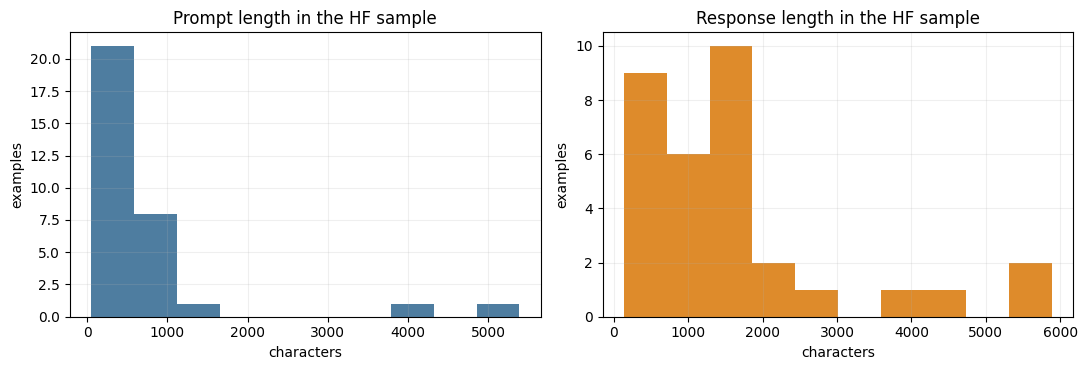

In [3]:
ultrachat_sample = load_dataset(HF_DATASET_ID, split="train_sft[:32]")


def first_turn(messages, role: str) -> str:
    for message in messages:
        if message.get("role") == role:
            return str(message.get("content", ""))
    return ""


sample_rows = []
for row in ultrachat_sample:
    messages = row.get("messages", [])
    prompt = first_turn(messages, "user")
    response = first_turn(messages, "assistant")
    sample_rows.append({
        "prompt_chars": len(prompt),
        "response_chars": len(response),
        "turns": len(messages),
        "prompt_preview": prompt[:100].replace("\n", " "),
        "response_preview": response[:100].replace("\n", " "),
    })

sample_df = pd.DataFrame(sample_rows)
print(f"Loaded {len(sample_df)} public UltraChat examples from Hugging Face.")
display(sample_df[["prompt_preview", "response_preview", "turns"]].head(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(sample_df["prompt_chars"], bins=10, color="#2F6690", alpha=0.85)
axes[0].set(title="Prompt length in the HF sample", xlabel="characters", ylabel="examples")
axes[1].hist(sample_df["response_chars"], bins=10, color="#D97706", alpha=0.85)
axes[1].set(title="Response length in the HF sample", xlabel="characters", ylabel="examples")
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()

display(sample_df[["prompt_chars", "response_chars", "turns"]].describe().round(1))


## 3. Public model loading and smoke test

`Qwen/Qwen2.5-0.5B-Instruct` is the base draft used in the Qwen2.5 KD objective study. The released Qwen3 draft is the JSD-trained `epfl-cs552-shallowseek/qwen3-06b-jsd-specdec` checkpoint. The final runtime study uses `Qwen/Qwen3-8B` as the target model, but the notebook does not reload the full target weights because the runtime section is designed to analyze precomputed summaries rather than rerun an expensive target-model evaluation. This section therefore loads the draft-side model configurations and the final tokenizer from Hugging Face. On the submitted GPU environment, the cell also performs a short generation to verify that the published draft checkpoint is usable.


In [4]:
qwen25_config = AutoConfig.from_pretrained(QWEN25_BASE_DRAFT_ID, trust_remote_code=False)
final_config = AutoConfig.from_pretrained(FINAL_DRAFT_ID, trust_remote_code=False)
final_tokenizer = AutoTokenizer.from_pretrained(FINAL_DRAFT_ID, trust_remote_code=False)

model_inventory = pd.DataFrame([
    {
        "role": "Qwen2.5 base draft",
        "hf_id": QWEN25_BASE_DRAFT_ID,
        "model_type": qwen25_config.model_type,
        "hidden_size": qwen25_config.hidden_size,
        "layers": qwen25_config.num_hidden_layers,
        "vocab_size": qwen25_config.vocab_size,
    },
    {
        "role": "final KD-trained draft",
        "hf_id": FINAL_DRAFT_ID,
        "model_type": final_config.model_type,
        "hidden_size": final_config.hidden_size,
        "layers": final_config.num_hidden_layers,
        "vocab_size": final_config.vocab_size,
    },
])
display(model_inventory)

if RUN_MODEL_SMOKE:
    final_draft = None
    inputs = None
    output = None
    continuation = None
    try:
        final_draft = AutoModelForCausalLM.from_pretrained(
            FINAL_DRAFT_ID,
            torch_dtype=torch.bfloat16,
            attn_implementation="sdpa",
            trust_remote_code=False,
        ).to("cuda").eval()

        prompt = "Explain speculative decoding in one concise sentence."
        formatted = final_tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}],
            tokenize=False,
            add_generation_prompt=True,
        )
        inputs = final_tokenizer(formatted, return_tensors="pt").to("cuda")
        with torch.inference_mode():
            output = final_draft.generate(
                **inputs,
                max_new_tokens=24,
                do_sample=False,
                pad_token_id=final_tokenizer.eos_token_id,
            )
        continuation = output[0, inputs.input_ids.shape[1]:]
        print("Smoke-test output:", final_tokenizer.decode(continuation, skip_special_tokens=True))
    except Exception as exc:
        print(f"Optional GPU smoke test skipped after load-time failure: {exc}")
    finally:
        del final_draft, inputs, output, continuation
        gc.collect()
        torch.cuda.empty_cache()
else:
    print("CUDA is unavailable, so only model configuration and tokenizer loading were performed.")


,role,hf_id,model_type,hidden_size,layers,vocab_size
0,Qwen2.5 base draft,Qwen/Qwen2.5-0.5B-Instruct,qwen2,896,24,151936
1,final KD-trained draft,epfl-cs552-shallowseek/qwen3-06b-jsd-specdec,qwen3,1024,28,151936


`torch_dtype` is deprecated! Use `dtype` instead!
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Smoke-test output: <think>
Okay, the user is asking for a concise explanation of speculative decoding in one sentence. Let me start by recalling


## 4. Qwen2.5 KD training analysis

This section summarizes two embedded Qwen2.5 analyses: an objective comparison across pretrained, FKL, RKL, and JSD drafts, and an additional KD-temperature ablation for FKL. The completed evaluation values are embedded below so this notebook does not depend on additional submitted data files.

All rows use the same protocol: 50 UltraChat prompts, `gamma=4`, `max_new_tokens=256`, one warmup, and three timing repeats. The custom Hugging Face loop exposes accepted-token statistics but includes Python and synchronization overhead, so these measurements compare KD objectives rather than production throughput.


### 4.1 Objective comparison


In [5]:
import pandas as pd

In [6]:
objective_df = pd.DataFrame([
    {
        "run": "pretrained",
        "acceptance_rate": 0.4503466557911909,
        "avg_accepted_tokens": 1.8013866231647635,
        "speedup": 0.5098640114382672,
        "tokens_per_second": 17.93123826437925,
    },
    {
        "run": "fkl",
        "acceptance_rate": 0.46133762219027487,
        "avg_accepted_tokens": 1.8453504887610995,
        "speedup": 0.5187090653566054,
        "tokens_per_second": 16.755988162192187,
    },
    {
        "run": "rkl",
        "acceptance_rate": 0.4588196105859055,
        "avg_accepted_tokens": 1.835278442343622,
        "speedup": 0.5157073642931166,
        "tokens_per_second": 16.473501655805175,
    },
    {
        "run": "jsd",
        "acceptance_rate": 0.47131637168219604,
        "avg_accepted_tokens": 1.8852654867287842,
        "speedup": 0.526774662996015,
        "tokens_per_second": 16.85799954720804,
    },
])

baseline = objective_df.iloc[0]
objective_df["acceptance_delta_vs_pretrained"] = objective_df["acceptance_rate"] - baseline["acceptance_rate"]
objective_df["accepted_tokens_delta_vs_pretrained"] = (
    objective_df["avg_accepted_tokens"] - baseline["avg_accepted_tokens"]
)
objective_df["speedup_delta_vs_pretrained"] = objective_df["speedup"] - baseline["speedup"]
display(objective_df.round(4))

objective_delta_df = (
    objective_df.loc[objective_df["run"] != "pretrained", [
        "run",
        "acceptance_delta_vs_pretrained",
        "accepted_tokens_delta_vs_pretrained",
        "speedup_delta_vs_pretrained",
    ]]
    .sort_values("acceptance_delta_vs_pretrained", ascending=False)
    .reset_index(drop=True)
)
display(objective_delta_df.round(4))

objective_rank_df = pd.DataFrame({
    "metric": ["acceptance_rate", "avg_accepted_tokens", "speedup", "tokens_per_second"],
    "best_run": [
        objective_df.loc[objective_df["acceptance_rate"].idxmax(), "run"],
        objective_df.loc[objective_df["avg_accepted_tokens"].idxmax(), "run"],
        objective_df.loc[objective_df["speedup"].idxmax(), "run"],
        objective_df.loc[objective_df["tokens_per_second"].idxmax(), "run"],
    ],
    "best_value": [
        objective_df["acceptance_rate"].max(),
        objective_df["avg_accepted_tokens"].max(),
        objective_df["speedup"].max(),
        objective_df["tokens_per_second"].max(),
    ],
})
display(objective_rank_df.round(4))

best = objective_df.loc[objective_df["acceptance_rate"].idxmax()]
print(
    f"Top acceptance run: {best['run']} ({best['acceptance_rate']:.3f}), "
    f"delta vs pretrained {best['acceptance_delta_vs_pretrained']:+.3f}."
)


,run,acceptance_rate,avg_accepted_tokens,speedup,tokens_per_second,acceptance_delta_vs_pretrained,accepted_tokens_delta_vs_pretrained,speedup_delta_vs_pretrained
0,pretrained,0.4503,1.8014,0.5099,17.9312,0.0000,0.0000,0.0000
1,fkl,0.4613,1.8454,0.5187,16.7560,0.0110,0.0440,0.0088
2,rkl,0.4588,1.8353,0.5157,16.4735,0.0085,0.0339,0.0058
3,jsd,0.4713,1.8853,0.5268,16.8580,0.0210,0.0839,0.0169


,run,acceptance_delta_vs_pretrained,accepted_tokens_delta_vs_pretrained,speedup_delta_vs_pretrained
0,jsd,0.0210,0.0839,0.0169
1,fkl,0.0110,0.0440,0.0088
2,rkl,0.0085,0.0339,0.0058


,metric,best_run,best_value
0,acceptance_rate,jsd,0.4713
1,avg_accepted_tokens,jsd,1.8853
2,speedup,jsd,0.5268
3,tokens_per_second,pretrained,17.9312


Top acceptance run: jsd (0.471), delta vs pretrained +0.021.


The objective comparison contains a consistent but modest signal. JSD is best on acceptance rate, average accepted tokens, and measured speedup among the KD-trained drafts, while the pretrained draft remains best on raw tokens per second. This separation is important: the training objective improves draft-target agreement metrics, but the instrumented Hugging Face backend still converts those gains into sub-`1x` wall-clock speedups.

The delta table is more informative than the absolute table alone. Relative to the pretrained draft, the largest gain is approximately `+0.021` in acceptance and `+0.084` in average accepted tokens for JSD, while the speedup gain remains only about `+0.017x`. The training-side conclusion is therefore stronger than the system-side conclusion: objective choice changes draft quality measurably, but backend overhead still dominates the end-to-end runtime metric in this setup.


### 4.2 FKL KD-temperature ablation

The objective sweep above is complemented by an additional FKL temperature comparison. Both embedded runs use the same UltraChat-50k setup and speculative-decoding evaluation protocol, so the difference isolates the KD temperature setting (`T=1` versus `T=2`).


In [7]:
fkl_temp_df = pd.DataFrame([
    {
        "run": "FKL, KD T=1",
        "kd_temperature": 1.0,
        "acceptance_rate": 0.4510233319688907,
        "avg_accepted_tokens": 1.8040933278755629,
        "speedup": 0.5094669917174816,
        "tokens_per_second": 17.68676113062409,
        "sd_time_s": 642.1752358227967,
        "vanilla_time_s": 327.16708555010456,
    },
    {
        "run": "FKL, KD T=2",
        "kd_temperature": 2.0,
        "acceptance_rate": 0.46133762219027487,
        "avg_accepted_tokens": 1.8453504887610995,
        "speedup": 0.5187090653566054,
        "tokens_per_second": 16.755988162192187,
        "sd_time_s": 673.5502434894443,
        "vanilla_time_s": 349.3763547965791,
    },
])

fkl_temp_delta = (
    fkl_temp_df.iloc[1][[
        "acceptance_rate",
        "avg_accepted_tokens",
        "speedup",
        "tokens_per_second",
        "sd_time_s",
        "vanilla_time_s",
    ]]
    - fkl_temp_df.iloc[0][[
        "acceptance_rate",
        "avg_accepted_tokens",
        "speedup",
        "tokens_per_second",
        "sd_time_s",
        "vanilla_time_s",
    ]]
)
display(fkl_temp_df.round(4))

fkl_temp_delta_df = pd.DataFrame([
    {
        "comparison": "T=2 minus T=1",
        "acceptance_delta": fkl_temp_delta["acceptance_rate"],
        "accepted_tokens_delta": fkl_temp_delta["avg_accepted_tokens"],
        "speedup_delta": fkl_temp_delta["speedup"],
        "tokens_per_second_delta": fkl_temp_delta["tokens_per_second"],
        "sd_time_s_delta": fkl_temp_delta["sd_time_s"],
        "vanilla_time_s_delta": fkl_temp_delta["vanilla_time_s"],
    }
])
display(fkl_temp_delta_df.round(4))

print(
    f"T=2 minus T=1: acceptance {fkl_temp_delta['acceptance_rate']:+.3f}, "
    f"avg accepted tokens {fkl_temp_delta['avg_accepted_tokens']:+.3f}, "
    f"speedup {fkl_temp_delta['speedup']:+.3f}x, "
    f"tokens/s {fkl_temp_delta['tokens_per_second']:+.3f}."
)


,run,kd_temperature,acceptance_rate,avg_accepted_tokens,speedup,tokens_per_second,sd_time_s,vanilla_time_s
0,"FKL, KD T=1",1.0,0.4510,1.8041,0.5095,17.6868,642.1752,327.1671
1,"FKL, KD T=2",2.0,0.4613,1.8454,0.5187,16.7560,673.5502,349.3764


,comparison,acceptance_delta,accepted_tokens_delta,speedup_delta,tokens_per_second_delta,sd_time_s_delta,vanilla_time_s_delta
0,T=2 minus T=1,0.0103,0.0413,0.0092,-0.9308,31.375,22.2093


T=2 minus T=1: acceptance +0.010, avg accepted tokens +0.041, speedup +0.009x, tokens/s -0.931.


The temperature ablation is weaker than the objective ablation, but it still shows a consistent directional effect on agreement metrics. For FKL on UltraChat 50k, moving from `T=1` to `T=2` increases acceptance by about `0.010` and average accepted tokens by about `0.041`, while measured speedup rises by only about `0.009x`. This is a small effect, but it is aligned with the interpretation that a softer teacher distribution can help FKL preserve more useful non-argmax probability mass.

The delta table also shows why this should not be oversold. `T=2` improves agreement and speedup slightly, but it reduces raw tokens per second and increases both speculative and vanilla evaluation time in these embedded runs. KD temperature matters, but its effect size in this setup is smaller than the effect of changing the KD objective, and neither change alone is enough to produce strong wall-clock gains in the instrumented backend.


## 5. `max_new_tokens` runtime ablation

This analysis asks one question: **how does the maximum continuation length affect speculative-decoding performance?**

The completed results are hosted publicly at `epfl-cs552-shallowseek/qwen3-8b-jsd-runtime-sweep-results`. This notebook downloads only the small `eval_summary.json` files, not generations or model weights. The target model for those evaluations is `Qwen/Qwen3-8B`, but the notebook uses the saved summaries directly instead of reloading the 8B model and rerunning speculative decoding.

Evaluation protocol:

- target: `Qwen/Qwen3-8B`
- draft: `epfl-cs552-shallowseek/qwen3-06b-jsd-specdec`
- backend: vLLM speculative decoding
- data: 50 held-out UltraChat prompts
- tested lengths: `max_new_tokens in {128,256,512}`
- each length uses the same 25 nuisance configurations and the same timing protocol
- timing: one warmup and three repeats

Other runtime settings are used only to form matched comparisons. This notebook does not draw separate conclusions about their individual effects.


In [8]:
runtime_snapshot = Path(snapshot_download(
    repo_id=RUNTIME_RESULTS_ID,
    repo_type="dataset",
    allow_patterns="qwen3_8b_jsd_runtime_sweep_all/*/eval_summary.json",
))

run_pattern = re.compile(
    r"_runtime_g(?P<gamma>\d+)_t(?P<temperature>\d+p\d+)_max(?P<max_new_tokens>\d+)$"
)
runtime_rows = []
for summary_path in runtime_snapshot.glob(
    "qwen3_8b_jsd_runtime_sweep_all/*/eval_summary.json"
):
    match = run_pattern.search(summary_path.parent.name)
    if not match:
        continue
    payload = json.loads(summary_path.read_text())
    runtime_rows.append({
        "gamma": int(match.group("gamma")),
        "temperature": float(match.group("temperature").replace("p", ".")),
        "max_new_tokens": int(match.group("max_new_tokens")),
        "speedup": payload["speedup"],
        "acceptance_rate": payload["acceptance_rate"],
        "avg_accepted_tokens": payload["avg_accepted_tokens"],
        "tokens_per_second": payload["tokens_per_second"],
        "sd_time_s": payload["sd_time_s"],
        "vanilla_time_s": payload["vanilla_time_s"],
        "n_prompts": payload["n_prompts"],
        "n_warmup": payload["n_warmup"],
        "n_repeats": payload["n_repeats"],
    })

runtime_all = pd.DataFrame(runtime_rows)
balanced_temperatures = {0.0, 0.5, 1.0, 1.5, 2.0}
runtime_df = runtime_all[
    runtime_all["temperature"].isin(balanced_temperatures)
    & runtime_all["max_new_tokens"].isin({128, 256, 512})
].copy()

assert len(runtime_df) == 75, f"Expected 75 balanced summaries, found {len(runtime_df)}"
assert runtime_df.groupby("max_new_tokens").size().to_dict() == {128: 25, 256: 25, 512: 25}
assert runtime_df["n_prompts"].unique().tolist() == [50]

print("Downloaded eval summaries:", len(runtime_all))
print("Balanced rows used for the length ablation:", len(runtime_df))
print("Rows per max_new_tokens:")
display(runtime_df.groupby("max_new_tokens").size().rename("configurations").to_frame())


Downloaded eval summaries: 85
Balanced rows used for the length ablation: 75
Rows per max_new_tokens:


,configurations
max_new_tokens,
128,25
256,25
512,25


### 5.0 Configuration interaction at a fixed length

Before aggregating across matched settings, this view shows the full `gamma × temperature` interaction surface at `max_new_tokens=256`. Cells above `1.0` indicate configurations where speculative decoding is faster than vanilla decoding.


temperature,0.0,0.5,1.0,1.5,2.0
gamma,,,,,
1,1.194,1.146,1.156,1.115,0.773
2,1.011,1.013,1.007,0.937,0.566
4,0.635,0.634,0.589,0.560,0.295
6,0.455,0.437,0.435,0.404,0.196
8,0.317,0.368,0.342,0.307,0.150


At max_new_tokens=256, 7/25 gamma-temperature settings beat vanilla decoding.


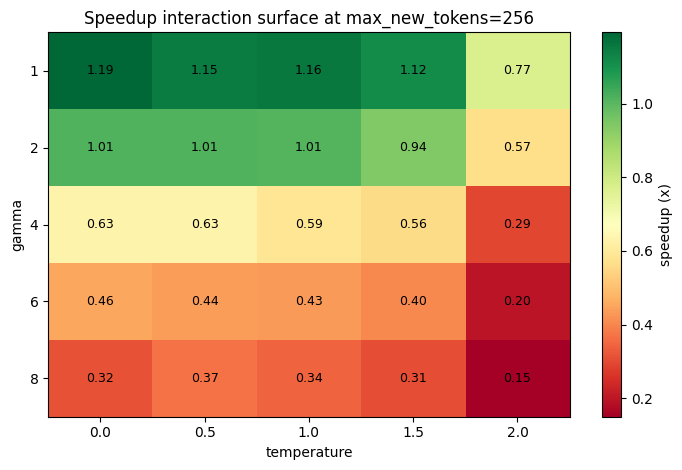

In [9]:
runtime_heatmap = (
    runtime_df[runtime_df["max_new_tokens"] == 256]
    .pivot(index="gamma", columns="temperature", values="speedup")
    .sort_index()
)
display(runtime_heatmap.round(3))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
im = ax.imshow(
    runtime_heatmap.values,
    cmap="RdYlGn",
    vmin=float(runtime_heatmap.values.min()),
    vmax=max(1.05, float(runtime_heatmap.values.max())),
    aspect="auto",
)
ax.set_xticks(range(len(runtime_heatmap.columns)))
ax.set_xticklabels(runtime_heatmap.columns)
ax.set_yticks(range(len(runtime_heatmap.index)))
ax.set_yticklabels(runtime_heatmap.index)
ax.set_xlabel("temperature")
ax.set_ylabel("gamma")
ax.set_title("Speedup interaction surface at max_new_tokens=256")
for i in range(runtime_heatmap.shape[0]):
    for j in range(runtime_heatmap.shape[1]):
        ax.text(j, i, f"{runtime_heatmap.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax, label="speedup (x)")
plt.tight_layout()

winning_configs = int((runtime_heatmap.values > 1.0).sum())
total_configs = int(runtime_heatmap.size)
print(f"At max_new_tokens=256, {winning_configs}/{total_configs} gamma-temperature settings beat vanilla decoding.")


### 5.1 Aggregate length effect

This section averages across the same 25 matched runtime configurations at each length. Error bars show one standard deviation across those configurations, so they describe sensitivity to the controlled nuisance settings rather than repeated-training uncertainty.


,max_new_tokens,mean_speedup,std_speedup,median_speedup,mean_acceptance,std_acceptance,mean_tokens_per_second,std_tokens_per_second
0,128,0.6527,0.3244,0.6131,0.4819,0.1901,335.4615,169.0292
1,256,0.6416,0.3350,0.5657,0.4087,0.1971,330.5083,175.8242
2,512,0.6316,0.3312,0.5469,0.3754,0.2051,315.2739,168.0087


128 to 512: mean acceptance -0.107, mean speedup -0.021x, mean throughput -20.2 tokens/s.


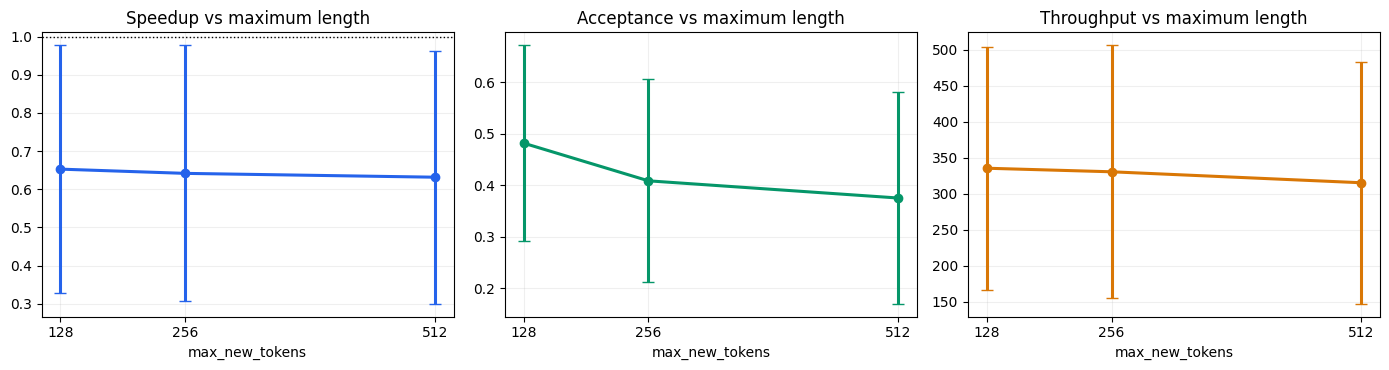

In [10]:
length_summary = (
    runtime_df.groupby("max_new_tokens", as_index=False)
    .agg(
        mean_speedup=("speedup", "mean"),
        std_speedup=("speedup", "std"),
        median_speedup=("speedup", "median"),
        mean_acceptance=("acceptance_rate", "mean"),
        std_acceptance=("acceptance_rate", "std"),
        mean_tokens_per_second=("tokens_per_second", "mean"),
        std_tokens_per_second=("tokens_per_second", "std"),
    )
)
display(length_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, mean_col, std_col, title, color in [
    (axes[0], "mean_speedup", "std_speedup", "Speedup vs maximum length", "#2563EB"),
    (axes[1], "mean_acceptance", "std_acceptance", "Acceptance vs maximum length", "#059669"),
    (
        axes[2], "mean_tokens_per_second", "std_tokens_per_second",
        "Throughput vs maximum length", "#D97706",
    ),
]:
    ax.errorbar(
        length_summary["max_new_tokens"],
        length_summary[mean_col],
        yerr=length_summary[std_col],
        marker="o",
        linewidth=2.2,
        capsize=4,
        color=color,
    )
    ax.set(xlabel="max_new_tokens", title=title, xticks=[128, 256, 512])
    ax.grid(alpha=0.2)
    if mean_col == "mean_speedup":
        ax.axhline(1.0, color="black", linestyle=":", linewidth=1)
plt.tight_layout()

indexed_length = length_summary.set_index("max_new_tokens")
delta_128_512 = indexed_length.loc[512] - indexed_length.loc[128]
print(
    f"128 to 512: mean acceptance {delta_128_512['mean_acceptance']:+.3f}, "
    f"mean speedup {delta_128_512['mean_speedup']:+.3f}x, "
    f"mean throughput {delta_128_512['mean_tokens_per_second']:+.1f} tokens/s."
)


### 5.1b Acceptance explains speedup variation

This view checks whether runtime degradation at larger generation budgets is primarily associated with lower draft-target agreement. The color coding shows that longer budgets cluster toward lower acceptance and lower speedup, while residual scatter reflects backend effects beyond acceptance alone.


Correlation between acceptance rate and speedup: 0.929


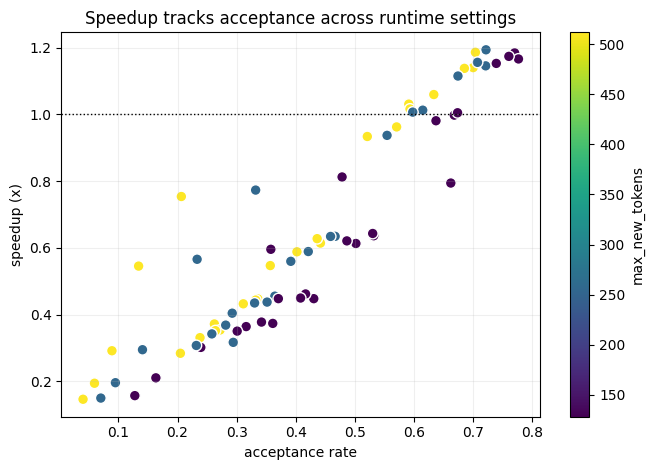

In [11]:
fig, ax = plt.subplots(figsize=(6.8, 4.8))
scatter = ax.scatter(
    runtime_df["acceptance_rate"],
    runtime_df["speedup"],
    c=runtime_df["max_new_tokens"],
    cmap="viridis",
    s=60,
    edgecolor="white",
)
ax.axhline(1.0, color="black", linestyle=":", linewidth=1)
ax.set_xlabel("acceptance rate")
ax.set_ylabel("speedup (x)")
ax.set_title("Speedup tracks acceptance across runtime settings")
fig.colorbar(scatter, ax=ax, label="max_new_tokens")
ax.grid(alpha=0.2)
plt.tight_layout()

acceptance_speedup_corr = runtime_df[["acceptance_rate", "speedup"]].corr().iloc[0, 1]
print(f"Correlation between acceptance rate and speedup: {acceptance_speedup_corr:.3f}")


### 5.2 Matched length changes

An aggregate mean can be distorted by different configurations. To isolate length more rigorously, each 128-token result is paired with the 256- and 512-token results that use the same remaining runtime settings. This matched view tests whether the length effect survives after holding the remaining runtime knobs fixed. The distributions below therefore measure within-configuration changes caused by increasing only `max_new_tokens`.


,mean,median,fraction_negative
speedup: 256 - 128,-0.0111,-0.0179,0.80
speedup: 512 - 128,-0.0211,-0.0220,0.84
acceptance: 256 - 128,-0.0732,-0.0659,1.00
acceptance: 512 - 128,-0.1066,-0.0939,1.00
throughput: 256 - 128,-4.9532,-7.8678,0.76
throughput: 512 - 128,-20.1876,-17.3713,0.92


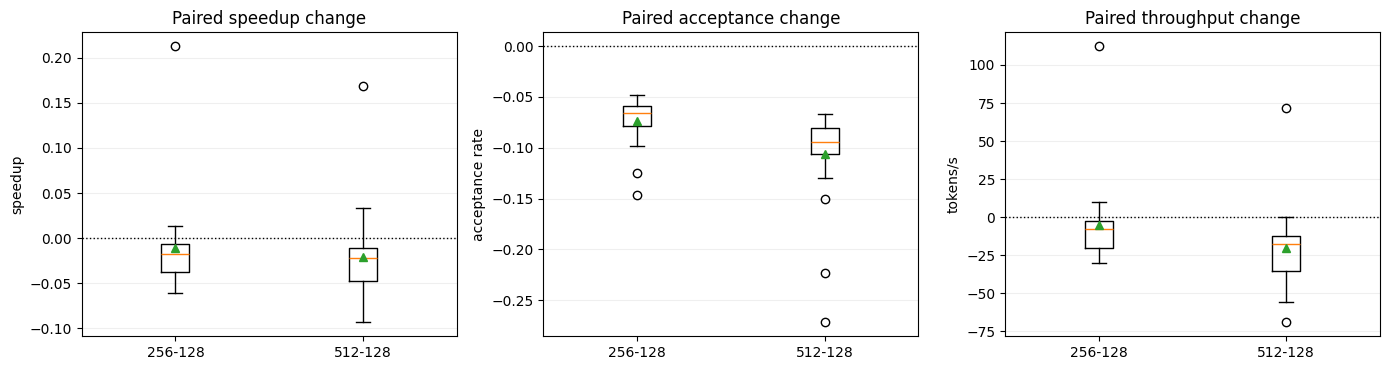

In [12]:
pair_key = ["gamma", "temperature"]
paired = runtime_df.pivot(
    index=pair_key,
    columns="max_new_tokens",
    values=["speedup", "acceptance_rate", "tokens_per_second"],
)

paired_changes = pd.DataFrame({
    "speedup: 256 - 128": paired[("speedup", 256)] - paired[("speedup", 128)],
    "speedup: 512 - 128": paired[("speedup", 512)] - paired[("speedup", 128)],
    "acceptance: 256 - 128": (
        paired[("acceptance_rate", 256)] - paired[("acceptance_rate", 128)]
    ),
    "acceptance: 512 - 128": (
        paired[("acceptance_rate", 512)] - paired[("acceptance_rate", 128)]
    ),
    "throughput: 256 - 128": (
        paired[("tokens_per_second", 256)] - paired[("tokens_per_second", 128)]
    ),
    "throughput: 512 - 128": (
        paired[("tokens_per_second", 512)] - paired[("tokens_per_second", 128)]
    ),
})

paired_change_summary = pd.DataFrame({
    "mean": paired_changes.mean(),
    "median": paired_changes.median(),
    "fraction_negative": (paired_changes < 0).mean(),
})
display(paired_change_summary.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
plot_groups = [
    (["speedup: 256 - 128", "speedup: 512 - 128"], "Paired speedup change", "speedup"),
    (
        ["acceptance: 256 - 128", "acceptance: 512 - 128"],
        "Paired acceptance change", "acceptance rate",
    ),
    (
        ["throughput: 256 - 128", "throughput: 512 - 128"],
        "Paired throughput change", "tokens/s",
    ),
]
for ax, (columns, title, ylabel) in zip(axes, plot_groups):
    ax.boxplot(
        [paired_changes[column] for column in columns],
        tick_labels=["256-128", "512-128"],
        showmeans=True,
    )
    ax.axhline(0.0, color="black", linestyle=":", linewidth=1)
    ax.set(title=title, ylabel=ylabel)
    ax.grid(axis="y", alpha=0.2)
plt.tight_layout()


### 5.3 Robustness relative to the vanilla baseline

This section measures how often speculative decoding remains faster than vanilla target decoding. This is a length-level reliability breakdown: each bar uses all 25 matched configurations for that maximum length.


,max_new_tokens,configurations,configurations_above_1x,fraction_above_1x,minimum_speedup,maximum_speedup
0,128,25,5,0.20,0.1570,1.1844
1,256,25,7,0.28,0.1497,1.1937
2,512,25,6,0.24,0.1462,1.1862


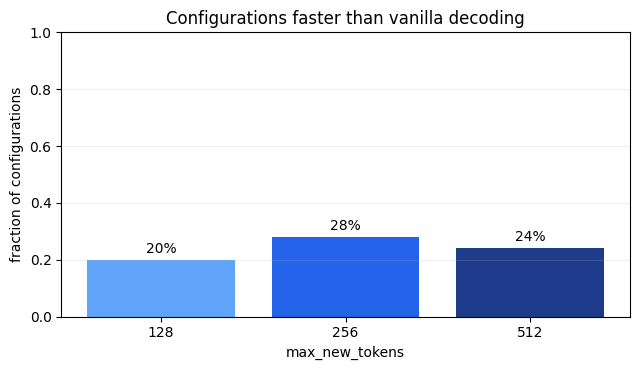

In [13]:
reliability = (
    runtime_df.assign(beats_vanilla=runtime_df["speedup"] > 1.0)
    .groupby("max_new_tokens", as_index=False)
    .agg(
        configurations=("speedup", "size"),
        configurations_above_1x=("beats_vanilla", "sum"),
        fraction_above_1x=("beats_vanilla", "mean"),
        minimum_speedup=("speedup", "min"),
        maximum_speedup=("speedup", "max"),
    )
)
display(reliability.round(4))

fig, ax = plt.subplots(figsize=(6.5, 3.8))
bars = ax.bar(
    reliability["max_new_tokens"].astype(str),
    reliability["fraction_above_1x"],
    color=["#60A5FA", "#2563EB", "#1E3A8A"],
)
ax.set(
    xlabel="max_new_tokens",
    ylabel="fraction of configurations",
    title="Configurations faster than vanilla decoding",
    ylim=(0, 1),
)
ax.grid(axis="y", alpha=0.2)
for bar, value in zip(bars, reliability["fraction_above_1x"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.025, f"{value:.0%}", ha="center")
plt.tight_layout()


### Runtime interpretation

Three points matter in this maximum-length ablation:

1. Longer generation budgets reduce mean acceptance, throughput, and average speedup. The aggregate summary shows that moving from `max_new_tokens=128` to `512` lowers balanced mean acceptance by about `0.107` and throughput by about `20` tokens/s.
2. The matched comparison shows that this is not only an averaging artifact. Within fixed `gamma` and temperature settings, increasing `max_new_tokens` usually makes the paired deltas for acceptance and speedup negative.
3. The robustness view is stronger than the best-case view. Some long-budget settings still achieve competitive speedups, but the fraction of configurations that beat vanilla decoding falls as the generation budget increases. A single headline speedup therefore hides how much stability is lost.

Taken together, these results suggest that `max_new_tokens` behaves less like a neutral cap and more like a runtime-risk variable. Longer continuations create more opportunities for draft-target disagreement and verification overhead, and the acceptance-speedup scatter shows that lower agreement is closely associated with weaker speedup. Because `max_new_tokens` is an upper bound rather than the realized output length, this should be interpreted as a runtime-budget effect rather than a token-by-token causal estimate.


## 6. Reproducibility record

The commands below document how the expensive Qwen2.5 artifacts were produced. They are shown as text and are not executed by this notebook.

```bash
# Qwen2.5 FKL training example
python scripts/train.py \
  loss=fkl data=ultrachat_50k \
  train.max_steps=8000 train.alpha=1.0 train.temperature=2.0 \
  data.max_seq_len=512 run_name=fkl_ultra50k_s8000_seq512_a1_temp2

# Instrumented Qwen2.5 evaluation
python scripts/evaluate_sd.py \
  draft=checkpoints/fkl_ultra50k_s8000_seq512_a1_temp2/model \
  prompts.jsonl=data/processed/ultrachat_50k/eval.jsonl \
  prompts.limit=50 runtime.gamma=4 runtime.max_new_tokens=256 \
  eval.n_warmup=1 eval.n_repeats=3
```

The final Qwen3 runtime summaries are loaded from the public Hugging Face dataset used above. Training and evaluation used one 40 GB NVIDIA A100. No model training or full benchmark is performed during notebook execution.


## 7. Limitations and conclusion

The Qwen2.5 objective comparison uses one training seed, so small differences may not survive repeated training. The final length sweep uses 50 held-out UltraChat prompts and one GPU/backend; absolute throughput should not be generalized to other hardware, batching policies, or prompt distributions. Early EOS also means realized generation lengths can be shorter than the configured maximum.

The controlled `max_new_tokens` ablation shows that the public JSD draft can provide real speedups, but longer generation budgets reduce acceptance and make speedup less robust across otherwise matched runtime configurations. Speculative-decoding evaluations should therefore report performance at multiple output-length budgets instead of relying on one headline speedup.
